<a href="https://colab.research.google.com/github/EsserMishelle/short-term-stock-forecast/blob/main/04_price_based_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Price-Based Linear Models
The objective of the price-based models is to evaluate whether machine learning methods using lagged price features and cross-asset signals can improve
short-term forecasts of NVDA stock prices compared to traditional time-series models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import seaborn as sns
import os
import time

### Load the Clean Dataset from Google Drive Obtained From Yahoo Finance

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Define folder path within the drive
folder_path = '/content/drive/MyDrive/stocks'
os.makedirs(folder_path, exist_ok=True)

# Define the assets folder path
assets_folder_path = '/content/drive/MyDrive/stocks/assets'
os.makedirs(assets_folder_path, exist_ok=True)

Mounted at /content/drive


In [3]:
# --- Load the clean and flatten file ---
all_stocks_ready_2021_2026_path = os.path.join(folder_path, 'all_stocks_ready_2021_2026.csv')

df = pd.read_csv(all_stocks_ready_2021_2026_path,
    index_col='Date',
    parse_dates=True
)
df

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume,qqq_open,qqq_high,qqq_low,qqq_close,qqq_volume,...,tsm_volume,amd_open,amd_high,amd_low,amd_close,amd_volume,vix_open,vix_high,vix_low,vix_close
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,13.067502,13.614215,12.926149,13.076726,560640000,305.791557,305.966256,296.155214,300.163086,45305900,...,11262100,92.110001,96.059998,90.919998,92.300003,51802600,23.040001,29.190001,22.559999,26.969999
2021-01-05,13.063014,13.405800,13.050300,13.367159,322760000,299.173289,302.909444,299.173289,302.637695,29323400,...,10583600,92.099998,93.209999,91.410004,92.769997,34208000,26.940001,28.600000,24.799999,25.340000
2021-01-06,13.185421,13.207858,12.550707,12.579126,580424000,297.921395,302.657089,296.931569,298.445435,52809600,...,10609300,91.620003,92.279999,89.459999,90.330002,51911700,25.480000,26.770000,22.139999,25.070000
2021-01-07,12.931133,13.340234,12.850361,13.306578,461480000,301.104442,306.500020,301.075331,305.665466,30394800,...,13556100,91.330002,95.510002,91.199997,95.160004,42897200,23.670000,23.910000,22.250000,22.370001
2021-01-08,13.325028,13.383364,13.005427,13.239518,292528000,307.955647,309.945042,305.762470,309.595673,33955800,...,18976800,95.980003,96.400002,93.269997,94.580002,39816400,22.430000,23.340000,21.420000,21.559999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-29,191.339996,193.479996,186.059998,192.509995,171764400,632.650024,633.669983,618.270020,629.429993,79944000,...,13844800,254.660004,260.529999,240.910004,252.179993,31685200,16.040001,19.740000,16.020000,16.879999
2026-01-30,191.210007,194.490005,189.470001,191.130005,179489500,625.710022,628.260010,619.299988,621.869995,65650700,...,12028100,236.929993,245.240005,234.550003,236.729996,40035700,18.719999,19.270000,16.670000,17.440001
2026-02-02,187.199997,190.300003,184.880005,185.610001,165794100,618.700012,628.489990,618.659973,626.140015,49020300,...,12459100,235.770004,249.970001,235.000000,246.270004,36308100,19.950001,19.959999,16.080000,16.340000


#### The time frame of the dataset is: 2021-01-04 to 2026-02-04.  There are 28 columns, 1278 rows and no null values.

#### Pearson Correlation Chart

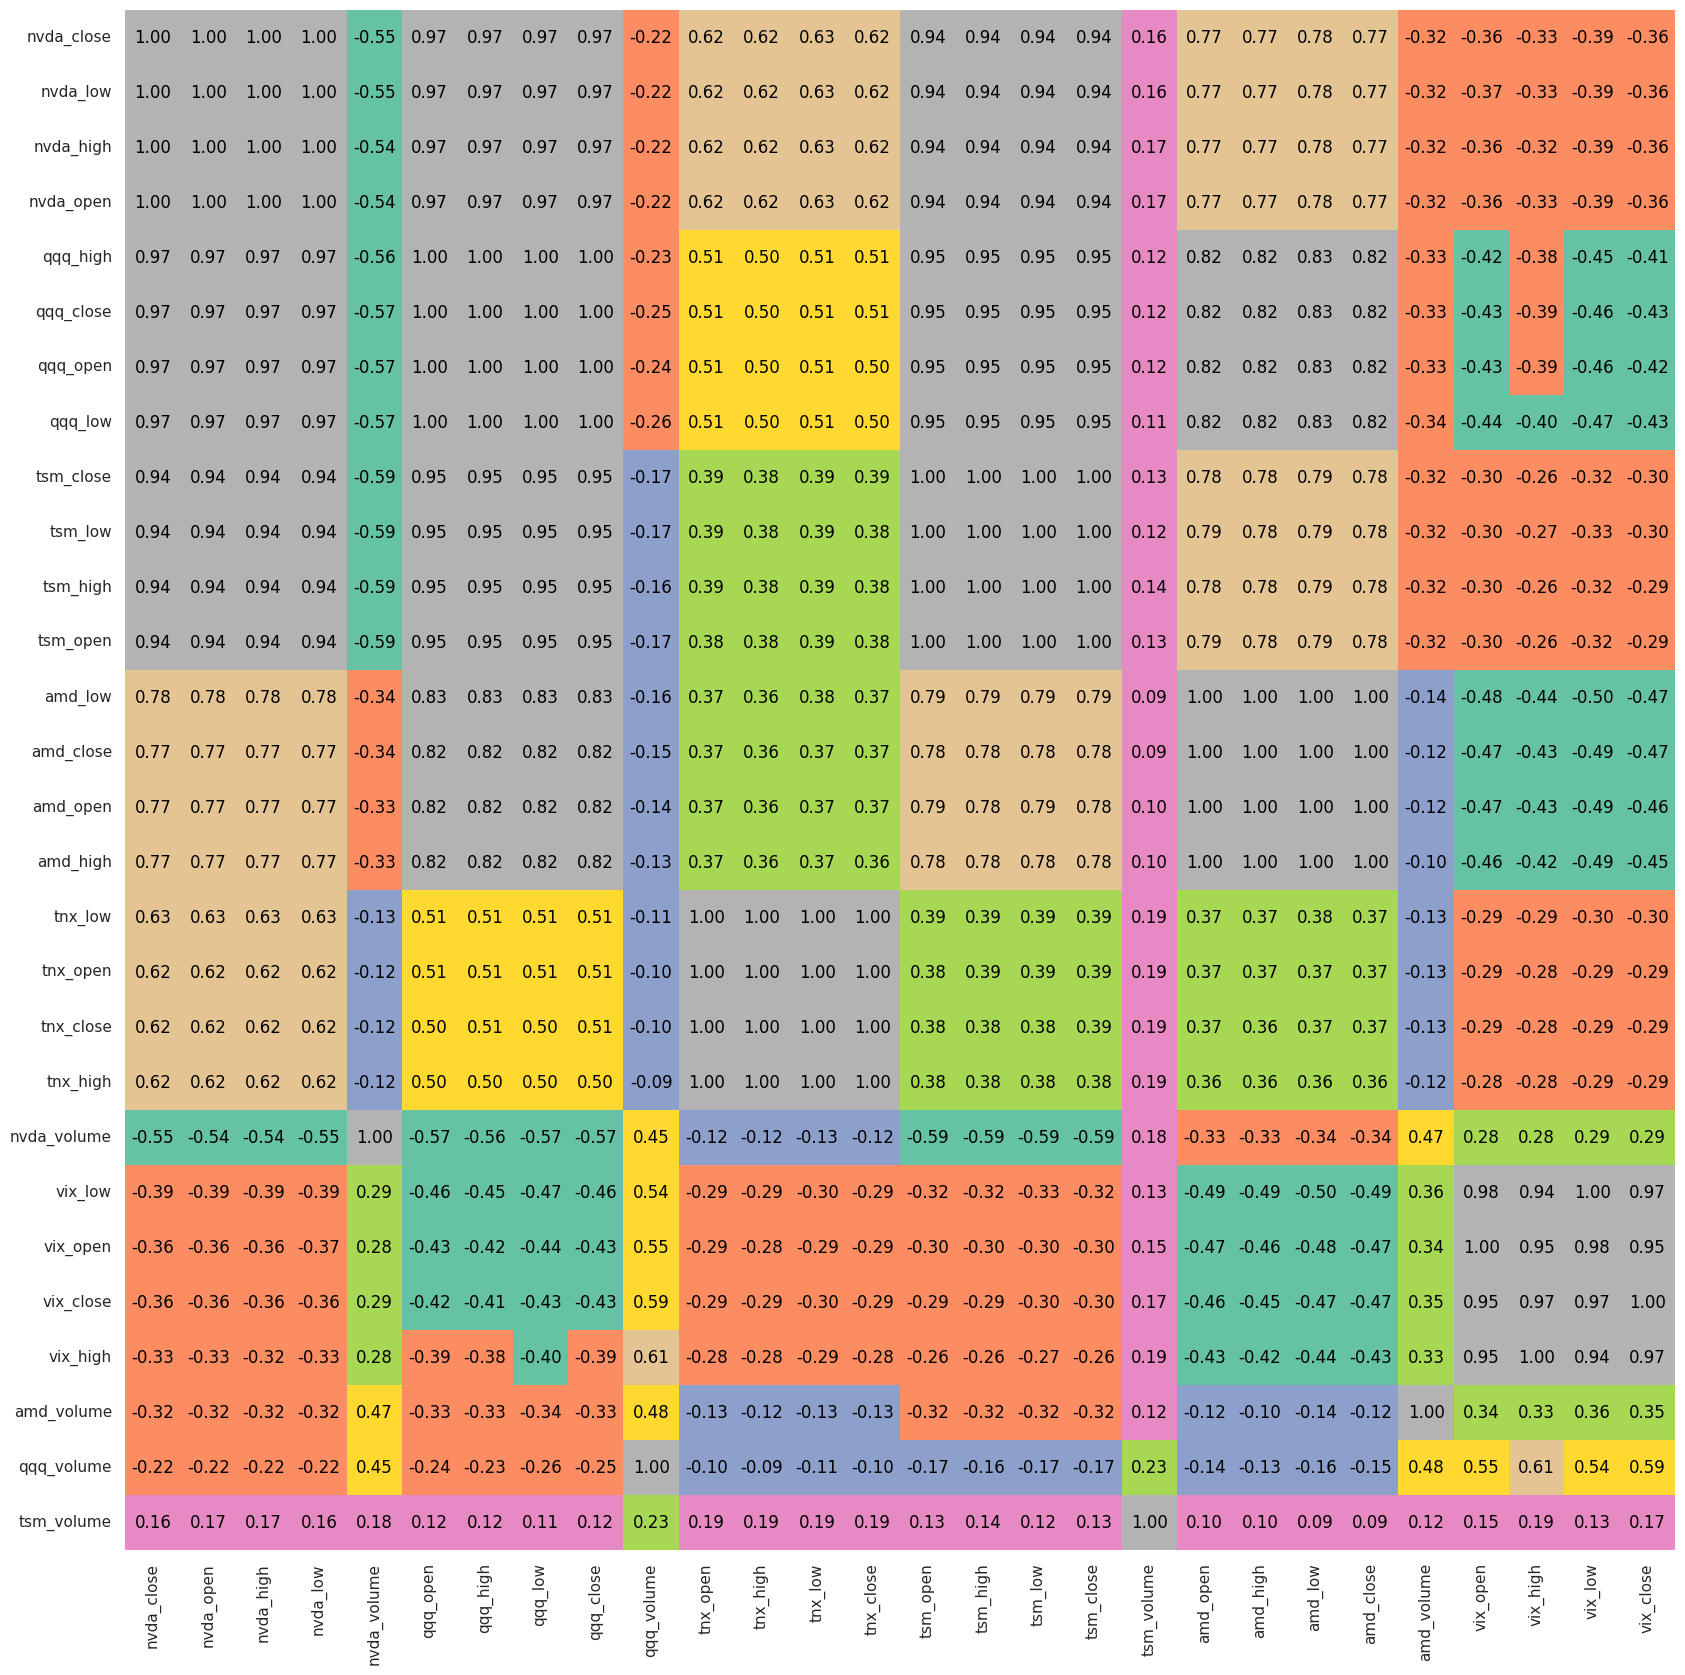

In [4]:
df_corr_raw = df.copy()
corr_matrix_raw = df_corr_raw.corr()
sorted_corr_raw = corr_matrix_raw.loc[
    corr_matrix_raw['nvda_close'].abs().sort_values(ascending=False).index
]
# Define 'cols' specifically for this heatmap, placing 'nvda_close' at the front
# cols_raw = col for col in sorted_corr_raw.columns
cols_raw = ['nvda_close'] + [col for col in sorted_corr_raw.columns if col != 'nvda_close']
df_heatmap_raw = sorted_corr_raw[cols_raw]
sns.set_theme(style="darkgrid")
plt.figure(figsize=(20,20))
sns.heatmap(df_heatmap_raw, annot=True, cmap='Set2', annot_kws={'fontsize': 12, 'color': 'black'}, fmt='.2f',  cbar=False)
plt.savefig(os.path.join(assets_folder_path, 'heatmap.jpg'))
plt.show()

##### Feature Correlation Analysis:

The correlation matrix highlights strong relationships between NVDA prices and other semiconductor-sector assets. NVDA shows very high positive correlations with QQQ and TSM (0.94-0.97) and moderately strong correlations with AMD (0.77-0.79), indicating that semiconductor stocks tend to move together and are influenced by broader technology market trends.

Interest rate indicators such as TNX show weaker positive correlations with NVDA, indicting lesser influence on NVDA price movements. In contrast, volatility measures (VIX) show a weak negative relationship with NVDA prices, consistent with the typical inverse relationship between market volatility and equity prices.

These correlations motivate the inclusion of cross-asset features (AMD, TSM, QQQ) in the machine learning models to capture broader market dynamics that may improve price forecasting performance.

### Models Evaluated
Three price-based models are evaluated with increasing feature complexity.
#### NVDA-Only Linear Regression
This model uses only lagged NVDA price features to forecast future prices in order to test whether a simple autoregressive ML model can outperform classical time-series models.

In [5]:
# Feature Engineer (NVDA-Only)
# Lagged prices (autoregressive features)

df['nvda_lag1_price'] = df['nvda_close'].shift(1)
df['nvda_lag2_price'] = df['nvda_close'].shift(2)
df['nvda_lag3_price'] = df['nvda_close'].shift(3)
df['nvda_lag5_price'] = df['nvda_close'].shift(5)
df['nvda_lag10_price'] = df['nvda_close'].shift(10)
df['nvda_lag20_price'] = df['nvda_close'].shift(20)

df['nvda_lag1_high_price'] = df['nvda_high'].shift(1)
df['nvda_lag2_low_price'] = df['nvda_low'].shift(2)
# Lagged Volumes
df['nvda_lag1_volume'] = df['nvda_volume'].shift(1)
df['nvda_lag2_volume'] = df['nvda_volume'].shift(2)
df['nvda_lag3_volume'] = df['nvda_volume'].shift(3)
df['nvda_lag5_volume'] = df['nvda_volume'].shift(5)
df['nvda_lag10_volume'] = df['nvda_volume'].shift(10)
df['nvda_lag20_volume'] = df['nvda_volume'].shift(20)

# Moving Avg (Different timeframe trends indicators)
df['nvda_roll2_price'] = df['nvda_close'].rolling(2).mean().shift(1)
df['nvda_roll3_price'] = df['nvda_close'].rolling(3).mean().shift(1)
df['nvda_roll5_price'] = df['nvda_close'].rolling(5).mean().shift(1)
df['nvda_roll10_price'] = df['nvda_close'].rolling(10).mean().shift(1)
df['nvda_roll20_price'] = df['nvda_close'].rolling(20).mean().shift(1)

# Distance from a longer moving average
df['nvda_roll2_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll2_price']
df['nvda_roll3_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll3_price']
df['nvda_roll5_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll5_price']
df['nvda_roll10_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll10_price']
df['nvda_roll20_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll20_price']

# How much is price fluctuating?
# Pirce Std - Magnitude Clustering
df['nvda_price_std2'] = df['nvda_close'].rolling(2).std().shift(1)
df['nvda_price_std3'] = df['nvda_close'].rolling(3).std().shift(1)
df['nvda_price_std5'] = df['nvda_close'].rolling(5).std().shift(1)   # Short-term price
df['nvda_price_std10'] = df['nvda_close'].rolling(10).std().shift(1)
df['nvda_price_std20'] = df['nvda_close'].rolling(20).std().shift(1) # Longer-term price

# Return Std - Relative Price Volatility Regime
df['nvda_volatility2'] = df['nvda_close'].pct_change().rolling(2).std().shift(1)
df['nvda_volatility3'] = df['nvda_close'].pct_change().rolling(3).std().shift(1)
df['nvda_volatility5'] = df['nvda_close'].pct_change().rolling(5).std().shift(1)
df['nvda_volatility10'] = df['nvda_close'].pct_change().rolling(10).std().shift(1)
df['nvda_volatility20'] = df['nvda_close'].pct_change().rolling(20).std().shift(1)

# MACD (Moving Average Convergence Divergence)
df['nvda_ema2'] = df['nvda_close'].ewm(span=2, adjust=False).mean().shift(1)
df['nvda_ema3'] = df['nvda_close'].ewm(span=3, adjust=False).mean().shift(1)
df['nvda_ema5'] = df['nvda_close'].ewm(span=5, adjust=False).mean().shift(1)
df['nvda_ema10'] = df['nvda_close'].ewm(span=10, adjust=False).mean().shift(1)
df['nvda_ema20'] = df['nvda_close'].ewm(span=20, adjust=False).mean().shift(1)

# Price Changes
df['nvda_lag1_return'] = df['nvda_close'].pct_change().shift(1)
df['nvda_lag2_return'] = df['nvda_close'].pct_change().shift(2)
df['nvda_lag3_return'] = df['nvda_close'].pct_change().shift(3)
df['nvda_lag5_return'] = df['nvda_close'].pct_change().shift(5)
df['nvda_lag10_return'] = df['nvda_close'].pct_change().shift(10)
df['nvda_lag20_return'] = df['nvda_close'].pct_change().shift(20)

# Trading activity signals
df['nvda_volume_ma2'] = df['nvda_volume'].rolling(2).mean().shift(1)
df['nvda_volume_ma3'] = df['nvda_volume'].rolling(3).mean().shift(1)
df['nvda_volume_ma5'] = df['nvda_volume'].rolling(5).mean().shift(1)
df['nvda_volume_ma20'] = df['nvda_volume'].rolling(20).mean().shift(1)
df['nvda_volume_ma30'] = df['nvda_volume'].rolling(30).mean().shift(1)

df['nvda_price_volume'] = df['nvda_close'].shift(1) * df['nvda_volume'].shift(1)  # Dollar volume
df['nvda_price_volume_ma2'] = df['nvda_price_volume'].rolling(2).mean().shift(1)
df['nvda_price_volume_ma3'] = df['nvda_price_volume'].rolling(3).mean().shift(1)
df['nvda_price_volume_ma5'] = df['nvda_price_volume'].rolling(5).mean().shift(1)
df['nvda_price_volume_ma10'] = df['nvda_price_volume'].rolling(10).mean().shift(1)
df['nvda_price_volume_ma20'] = df['nvda_price_volume'].rolling(20).mean().shift(1)
df['nvda_price_volume_ma30'] = df['nvda_price_volume'].rolling(30).mean().shift(1)

# High-Low range (shifted to avoid data leakage)
df['nvda_high_low_range'] = (df['nvda_high'].shift(1) - df['nvda_low'].shift(1))
df['nvda_high_low_pct'] = ((df['nvda_high'] - df['nvda_low']) / df['nvda_close']).shift(1)

# Indicators
# RSI (Relative Strength Index)
delta = df['nvda_close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['nvda_rsi'] = 100 - (100 / (1 + rs))
df['nvda_rsi'] = df['nvda_rsi'].shift(1)  # Avoid look-ahead bias

# MACD
exp1 = df['nvda_close'].ewm(span=5, adjust=False).mean()
exp2 = df['nvda_close'].ewm(span=10, adjust=False).mean()
df['nvda_macd'] = exp1 - exp2
df['nvda_macd'] = df['nvda_macd'].shift(1)

# Price Momentum
df['nvda_momentum1'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(2)
df['nvda_momentum2'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(3)
df['nvda_momentum3'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(4)
df['nvda_momentum5'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(6)
df['nvda_momentum10'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(11)

df['mom5_x_std2'] = df['nvda_momentum5'] * df['nvda_price_std2']
df['mom5_x_std3'] = df['nvda_momentum5'] * df['nvda_price_std3']
df['mom5_x_std5'] = df['nvda_momentum5'] * df['nvda_price_std5']
df['mom5_x_std10'] = df['nvda_momentum5'] * df['nvda_price_std10']
df['mom5_x_std20'] = df['nvda_momentum5'] * df['nvda_price_std20']

# Calendar Features
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['day_of_month'] = df.index.day


# Peer Price
df['amd_lag1_price'] = df['amd_close'].shift(1)
df['tsm_lag1_price'] = df['tsm_close'].shift(1)
df['qqq_lag1_price'] = df['qqq_close'].shift(1)
df['vix_lag1_price'] = df['vix_close'].shift(1)
df['tnx_lag1_price'] = df['tnx_close'].shift(1)

df['tsm_lag2_price'] = df['tsm_close'].shift(2)
df['qqq_lag2_price'] = df['qqq_close'].shift(2)

df['vix_lag5_price'] = df['vix_close'].shift(5)
df['vix_lag10_price'] = df['vix_close'].shift(10)
df['vix_lag15_price'] = df['vix_close'].shift(15)

df['tnx_lag5_price'] = df['tnx_close'].shift(5)
df['tnx_lag10_price'] = df['tnx_close'].shift(10)
df['tnx_lag14_price'] = df['tnx_close'].shift(14)
df['tnx_lag15_price'] = df['tnx_close'].shift(15)

# Peer stock rolling trends
df['qqq_roll3_price'] = df['qqq_close'].rolling(3).mean().shift(1)
df['qqq_roll5_price'] = df['qqq_close'].rolling(5).mean().shift(1)

df['amd_roll3_price'] = df['amd_close'].rolling(3).mean().shift(1)
df['amd_roll5_price'] = df['amd_close'].rolling(5).mean().shift(1)

df['tsm_roll3_price'] = df['tsm_close'].rolling(3).mean().shift(1)
df['tsm_roll5_price'] = df['tsm_close'].rolling(5).mean().shift(1)
df['tsm_roll10_price'] = df['tsm_close'].rolling(10).mean().shift(1)
df['tsm_roll20_price'] = df['tsm_close'].rolling(10).mean().shift(1)

df['amd_ema10'] = df['amd_close'].ewm(span=10, adjust=False).mean().shift(1)
df['tsm_ema20'] = df['tsm_close'].ewm(span=20, adjust=False).mean().shift(1)

# peer risk & rates
df['tsm_price_std2'] = df['tsm_close'].rolling(2).std().shift(1)
df['tsm_price_std3'] = df['tsm_close'].rolling(3).std().shift(1)
df['tsm_price_std5'] = df['tsm_close'].rolling(5).std().shift(1)   # Short-term price
df['tsm_price_std10'] = df['tsm_close'].rolling(10).std().shift(1)
df['tsm_price_std20'] = df['tsm_close'].rolling(20).std().shift(1)

# return qqq Std - Relative Price Volatility Regime
df['qqq_volatility2'] = df['qqq_close'].pct_change().rolling(2).std().shift(1)
df['qqq_volatility3'] = df['qqq_close'].pct_change().rolling(3).std().shift(1)
df['qqq_volatility5'] = df['qqq_close'].pct_change().rolling(5).std().shift(1)
df['qqq_volatility10'] = df['qqq_close'].pct_change().rolling(10).std().shift(1)
df['qqq_volatility20'] = df['qqq_close'].pct_change().rolling(20).std().shift(1)


# return tsm Std - Relative Price Volatility Regime
df['tsm_volatility2'] = df['tsm_close'].pct_change().rolling(2).std().shift(1)
df['tsm_volatility3'] = df['tsm_close'].pct_change().rolling(3).std().shift(1)
df['tsm_volatility5'] = df['tsm_close'].pct_change().rolling(5).std().shift(1)
df['tsm_volatility10'] = df['tsm_close'].pct_change().rolling(10).std().shift(1)
df['tsm_volatility20'] = df['tsm_close'].pct_change().rolling(20).std().shift(1)

df['tnx_lag14_price'] = df['tnx_close'].shift(14)

df = df.copy()
df = df.sort_index()

# time index (t) is added to model long-term price drift
df['t'] = np.arange(len(df));

display(df.head())
print()
display(df.tail())
display(df.shape);

/tmp/ipykernel_336/2838185980.py:151: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tsm_ema20'] = df['tsm_close'].ewm(span=20, adjust=False).mean().shift(1)
/tmp/ipykernel_336/2838185980.py:154: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tsm_price_std2'] = df['tsm_close'].rolling(2).std().shift(1)
/tmp/ipykernel_336/2838185980.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume,qqq_open,qqq_high,qqq_low,qqq_close,qqq_volume,...,qqq_volatility3,qqq_volatility5,qqq_volatility10,qqq_volatility20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20,t
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,13.067502,13.614215,12.926149,13.076726,560640000,305.791557,305.966256,296.155214,300.163086,45305900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2021-01-05,13.063014,13.405800,13.050300,13.367159,322760000,299.173289,302.909444,299.173289,302.637695,29323400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2021-01-06,13.185421,13.207858,12.550707,12.579126,580424000,297.921395,302.657089,296.931569,298.445435,52809600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2021-01-07,12.931133,13.340234,12.850361,13.306578,461480000,301.104442,306.500020,301.075331,305.665466,30394800,...,NaN,NaN,NaN,NaN,0.011034,NaN,NaN,NaN,NaN,3
2021-01-08,13.325028,13.383364,13.005427,13.239518,292528000,307.955647,309.945042,305.762470,309.595673,33955800,...,0.019105,NaN,NaN,NaN,0.017789,0.020567,NaN,NaN,NaN,4


,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume,qqq_open,qqq_high,qqq_low,qqq_close,qqq_volume,...,qqq_volatility3,qqq_volatility5,qqq_volatility10,qqq_volatility20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20,t
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-29,191.339996,193.479996,186.059998,192.509995,171764400,632.650024,633.669983,618.270020,629.429993,79944000,...,0.003057,0.002613,0.010132,0.008175,0.003689,0.012268,0.011466,0.023572,0.021918,1273
2026-01-30,191.210007,194.490005,189.470001,191.130005,179489500,625.710022,628.260010,619.299988,621.869995,65650700,...,0.007594,0.005463,0.009618,0.008294,0.013957,0.013163,0.013962,0.023285,0.022028,1274
2026-02-02,187.199997,190.300003,184.880005,185.610001,165794100,618.700012,628.489990,618.659973,626.140015,49020300,...,0.007719,0.008548,0.010489,0.008548,0.013041,0.019094,0.017321,0.020193,0.023127,1275
2026-02-03,186.240005,186.270004,176.229996,180.339996,204019600,628.299988,629.979980,610.960022,616.520020,81234000,...,0.009642,0.008945,0.010697,0.008635,0.041824,0.030264,0.022983,0.023163,0.021406,1276
2026-02-04,179.460007,179.580002,171.910004,174.190002,207014100,615.020020,615.099976,600.469971,605.750000,81850700,...,0.011985,0.009576,0.009435,0.009214,0.034723,0.031651,0.023619,0.018385,0.021826,1277


(1278, 143)

After feature-engineered, the timeframe is now from: 03-30-2021 to 02-04-2026. There are 143 columns and 1278 rows.

##### Correlation by NVDA Last 30 Days Closing Price

In [6]:
# Feature used for corr() chart purpose
df_corr = df.copy()
df_corr['y_30'] = df_corr['nvda_close'].shift(-30)

# Drop NaNs before correlation
df_corr = df_corr.dropna()

corr_matrix = df_corr.corr()

# Sort by absolute correlation with y_30
sorted_corr = corr_matrix.loc[
    corr_matrix['y_30'].abs().sort_values(ascending=False).index
]

# Move y_30 column to the front
cols = ['y_30'] + [col for col in sorted_corr.columns if col != 'y_30']
df_heatmap = sorted_corr[cols]
df_heatmap.head(60)

,y_30,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume,qqq_open,qqq_high,qqq_low,qqq_close,...,qqq_volatility3,qqq_volatility5,qqq_volatility10,qqq_volatility20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20,t
y_30,1.000000,0.977594,0.977973,0.978309,0.978620,-0.535836,0.948450,0.949739,0.948309,0.949220,...,-0.198949,-0.233463,-0.248960,-0.253853,0.058079,0.063347,0.083708,0.121784,0.148423,0.916814
nvda_close,0.978620,0.999315,0.999656,0.999734,1.000000,-0.539619,0.969441,0.970563,0.969203,0.970049,...,-0.195707,-0.234464,-0.258210,-0.272124,0.068981,0.072472,0.087249,0.127676,0.172137,0.907468
nvda_low,0.978309,0.999630,0.999588,1.000000,0.999734,-0.543720,0.970001,0.970751,0.969684,0.970088,...,-0.199699,-0.238830,-0.261916,-0.275303,0.065956,0.068437,0.082723,0.123142,0.168179,0.906682
nvda_high,0.977973,0.999751,1.000000,0.999588,0.999656,-0.534293,0.969647,0.970645,0.968895,0.969553,...,-0.193271,-0.232025,-0.256508,-0.270765,0.070635,0.074947,0.090009,0.129092,0.174474,0.907687
nvda_lag1_price,0.977636,0.999579,0.999409,0.999217,0.998970,-0.539005,0.969772,0.970467,0.968900,0.969298,...,-0.195041,-0.233649,-0.257666,-0.271727,0.069655,0.074383,0.089178,0.126392,0.171356,0.907113
nvda_open,0.977594,1.000000,0.999751,0.999630,0.999315,-0.538062,0.970079,0.970658,0.969163,0.969499,...,-0.195814,-0.235039,-0.259032,-0.273261,0.069523,0.072931,0.087072,0.126074,0.171080,0.906777
nvda_ema2,0.977518,0.999440,0.999346,0.999080,0.998904,-0.539087,0.969781,0.970544,0.968891,0.969339,...,-0.194638,-0.233590,-0.257196,-0.271585,0.069920,0.074862,0.090042,0.126589,0.171119,0.907262
nvda_roll2_price,0.977407,0.999295,0.999236,0.998966,0.998817,-0.539118,0.969654,0.970431,0.968793,0.969253,...,-0.194938,-0.233891,-0.257303,-0.271618,0.069346,0.074466,0.089792,0.126316,0.171066,0.907164
nvda_ema3,0.977333,0.999241,0.999197,0.998865,0.998739,-0.539051,0.969715,0.970534,0.968787,0.969282,...,-0.193745,-0.232994,-0.256492,-0.271297,0.070754,0.075808,0.091194,0.127163,0.170916,0.907323
nvda_roll3_price,0.977088,0.999013,0.998986,0.998639,0.998520,-0.538971,0.969516,0.970338,0.968592,0.969079,...,-0.194261,-0.233568,-0.256678,-0.271375,0.070138,0.075214,0.090870,0.126668,0.170842,0.907144


The 30-day target is most strongly correlated with NVDA’s own lagged and rolling price features, confirming the dominance of autoregressive structure in price forecasting. Cross-asset features (QQQ, TSM, AMD) and volatility measures exhibit weaker but still meaningful correlations, indicating potential secondary predictive influence.

### Time-Based Train-Test-Split
#### The dataset was split chronologically, using Feb 3, 2025 as the cutoff point, to create a sufficiently long training window while preserving a meaningful out-of-sample period for testing. This preserves data integrity and prevents look-ahead bias in the time-series evaluation.

In [7]:
split_date = pd.to_datetime('2025-02-03') # first business date in Feb, 2025

MAE, RSME, MAPE Metric Function

In [8]:
def evaluate_direct_price_model(
    df,
    feature_cols,
    horizon,
    split_date,
    model,
    scale=False
):

    df_model = df.copy()

    # Create dynamic target
    df_model['y'] = df_model['nvda_close'].shift(-horizon)

    # Keep only needed columns
    df_model = df_model[feature_cols + ['y']]

    # Drop NaNs safely
    df_model = df_model.dropna()

    # Split
    train = df_model[df_model.index < split_date]
    test  = df_model[df_model.index >= split_date]

    X_train = train[feature_cols]
    y_train = train['y']

    X_test  = test[feature_cols]
    y_test  = test['y']

    # Optional scaling (for Lasso / Ridge)
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

    # Fit model
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    results = {
        "Horizon": horizon,
        "Train_MAE": mean_absolute_error(y_train, y_pred_train),
        "Test_MAE":  mean_absolute_error(y_test, y_pred_test),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "Test_RMSE":  np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "Train_MAPE": mean_absolute_percentage_error(y_train, y_pred_train),
        "Test_MAPE":  mean_absolute_percentage_error(y_test, y_pred_test)
    }

    return results, model, test.index, y_test, y_pred_test

## Linear Regression Price-Based Models

### 1. Baseline: NVDA-Only Features Model  
#### Uses only NVDA’s historical price and technical features.

In [9]:
X_cols_uni = [
'nvda_lag1_price',

# Lagged Volumes
'nvda_lag2_volume',

# Moving Avg (Different timeframe trends indicators)
'nvda_roll3_dist_price',

# How much is price fluctuating?
'nvda_price_std2',

# Price Regime Volatility
'nvda_volatility2',
'nvda_volatility3',
'nvda_volatility5',
'nvda_volatility10',
'nvda_volatility20',

# MACD (Moving Average Convergence Divergence)
'nvda_ema2', #deleted

# Trading activity signals
'nvda_volume_ma20',

# Indicators
## RSI (Relative Strength Index)
'nvda_rsi' ,  # Avoid look-ahead bias  # deleted

# Price Momentum

'nvda_momentum5',
# 'nvda_momentum10',

'mom5_x_std10',
't',

'nvda_ema5',

]

### 2. Extended: NVDA + Cross-Asset Features Model  
#### Incorporates selected NVDA, peer, and market signals.

In [10]:
X_cols_mul = [
'nvda_lag1_price',
'nvda_lag2_price',

# Moving Avg (Different timeframe trends indicators)
'nvda_roll3_price',

# How much is price fluctuating?
'nvda_price_std2',

# Price Regime Volatility
'nvda_volatility3',

# MACD (Moving Average Convergence Divergence)
'nvda_ema20',

# Price Changes
'nvda_lag5_return',

# Trading activity signals
'nvda_volume_ma30',

# High-Low range (shifted to avoid data leakage)
'nvda_high_low_range',

# MACD
'nvda_macd',

# Price Momentum
'nvda_momentum10',
'mom5_x_std20',

# Peer Price
'tsm_close',
'tnx_lag15_price',
'qqq_close',

# Price Regime
'qqq_roll5_price',
'tsm_roll10_price',
'tsm_ema20' ,
'tsm_price_std20',
'tsm_volatility2',
'tsm_volatility3',
'tsm_volatility5',
'tsm_volatility10',
'tsm_volatility20',

't',

'tnx_lag15_price',
]

#### Compare Both NVDA-Only and NVDA + Cross Asset Models

In [11]:
# Horizons (Various timeframes)
horizons = [1, 5, 10, 20, 30]

# NVDA Only Model
results_lr_uni = []

for h in horizons:
    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        model=LinearRegression(),
        feature_cols=X_cols_uni,
        horizon=h,
        split_date=split_date,
        scale=False
    )
    results_lr_uni.append(metrics)

price_lr_uni_df = pd.DataFrame(results_lr_uni)
print('========================= NVDA Features LR Model ========================')
display(price_lr_uni_df)
print()

# NVDA + Cross Asset Model
results_lr_mul = []

for h in horizons:
    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        model = LinearRegression(),
        feature_cols=X_cols_mul,
        horizon=h,
        split_date=split_date,
        scale=False
    )
    results_lr_mul.append(metrics)

price_lr_mul_df = pd.DataFrame(results_lr_mul)
print('================== NVDA + Cross Asset Features LR Model ================')
display(price_lr_mul_df)


price_lr_uni_df.to_csv(
    os.path.join(folder_path, "price_based_lr_uni_results.csv"),
    index=False
)

price_lr_mul_df.to_csv(
    os.path.join(folder_path,"price_based_lr_mul_results.csv"),
    index=False
)

========================= NVDA Features LR Model ========================


,Horizon,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,1,1.727115,4.013615,2.830723,5.179395,0.039445,0.027110
1,5,2.942056,6.581162,4.632206,8.366870,0.067881,0.044756
2,10,3.856185,8.473308,5.931200,10.603721,0.091402,0.057579
3,20,5.201606,11.609037,7.794316,13.714031,0.125035,0.080361
4,30,6.320913,14.021861,9.517919,16.984614,0.149767,0.096125



================== NVDA + Cross Asset Features LR Model ================


,Horizon,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,1,1.665695,3.729036,2.690231,4.873886,0.040032,0.024870
1,5,2.942375,6.605796,4.572735,8.312099,0.067560,0.044740
2,10,3.836428,9.606709,5.635885,11.842148,0.097534,0.065892
3,20,5.262252,13.157643,7.464378,15.923011,0.133620,0.092050
4,30,6.434173,14.284383,9.211387,17.570850,0.172939,0.100168


#### Interpretation:

- Cross-asset features provide meaningful gains at shorter horizons (1-5 days), indicating that market and peer signals enhance near-term predictive accuracy.
- At longer horizons (20-30 days), the advantage diminishes, implying that longer-term price movement is driven more by NVDA’s own trend structure than external signals..


### 3. Regularized: Lasso Regression  
#### Performs automatic feature selection and controls overfitting.


In [12]:
X_cols_lasso = [
'nvda_lag1_price',
'nvda_lag2_price',
'nvda_lag3_price',
'nvda_lag5_price',
'nvda_lag1_volume',
'nvda_lag2_volume',
'nvda_roll3_price',
'nvda_price_std2',
'nvda_volatility3',
'nvda_volatility10',
'nvda_volatility20',
'nvda_ema20',
'nvda_lag5_return',
'nvda_volume_ma2',
'nvda_volume_ma30',
'nvda_high_low_range',
'nvda_macd',
'nvda_momentum10',
'mom5_x_std20',
'tsm_close',
'qqq_close',
'qqq_roll5_price',
'tsm_roll10_price',
'tsm_ema20' ,
'qqq_lag1_price',
'tsm_lag2_price',
'tnx_lag1_price',
'tnx_lag5_price',
'tnx_lag14_price',
'tsm_price_std20',
'tsm_volatility2',
'tsm_volatility3',
'tsm_volatility5',
'tsm_volatility10',
'tsm_volatility20',
't',

]

In [13]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
results_lasso = []

for h in [1, 5, 10, 20, 30]:  # multiple horizons

    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        feature_cols=X_cols_lasso,
        horizon=h,
        split_date=split_date,
        model=Lasso(alpha=0.05, max_iter=10000, random_state=42),
        scale=True
    )
    results_lasso.append(metrics)


price_lasso_df = pd.DataFrame(results_lasso)
print('============== Lasso LR NVDA + Cross Asset Features Model ============')
display(price_lasso_df)

price_lasso_df.to_csv(
    os.path.join(folder_path,"price_based_lasso_results.csv"),
    index=False
)

============== Lasso LR NVDA + Cross Asset Features Model ============


,Horizon,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,1,1.691251,4.346490,2.806247,5.611399,0.037910,0.028725
1,5,2.906611,6.626560,4.581431,8.372529,0.066537,0.044821
2,10,3.813299,8.693734,5.686366,10.768857,0.095262,0.059777
3,20,5.260057,12.014342,7.520353,14.480081,0.133230,0.084489
4,30,6.308938,13.257079,9.273386,16.046756,0.165902,0.092474


In [14]:
print(len(X_cols_mul))
print(len(model.coef_))

26
36


#### Interpretation:

##### Lasso underperforms the cross-asset model at short horizons but becomes more competitive at longer horizons. The regularization effect improves generalization by limiting redundant predictors, resulting in more stable long-horizon forecasts.

In [16]:
alphas = [0.01, 0.05, 0.1, 0.5, 1, 5]

for a in alphas:
    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        feature_cols=X_cols_lasso,
        horizon=30,
        split_date=split_date,
        model=Lasso(alpha=a, max_iter=10000, random_state=42),
        scale=True
    )
    n_zero = np.sum(model.coef_ == 0)

    print(f"Alpha: {a:>4} | RMSE: {metrics['Test_RMSE']:.4f} | Zero Coefs: {n_zero}")

Alpha: 0.01 | RMSE: 17.0887 | Zero Coefs: 5
Alpha: 0.05 | RMSE: 16.0468 | Zero Coefs: 14
Alpha:  0.1 | RMSE: 16.3444 | Zero Coefs: 18
Alpha:  0.5 | RMSE: 16.9895 | Zero Coefs: 27
Alpha:    1 | RMSE: 17.8298 | Zero Coefs: 30
Alpha:    5 | RMSE: 24.1486 | Zero Coefs: 32


Moderate regularization (α ≈ 0.05–0.1) achieves the best tradeoff between bias and variance, whereas higher penalties lead to underfitting. Although regularization does not dramatically reduce forecast error, it simplifies and optimize the model.

### Find Coefficients in Lasso Regression

In [17]:
coef = model.coef_
sum(coef == 0)

np.int64(32)

,Feature,Coefficient,Abs_Coefficient
0,nvda_lag1_price,29.930261,29.930261
35,t,3.941717,3.941717
11,nvda_ema20,1.947586,1.947586
20,qqq_close,1.481287,1.481287


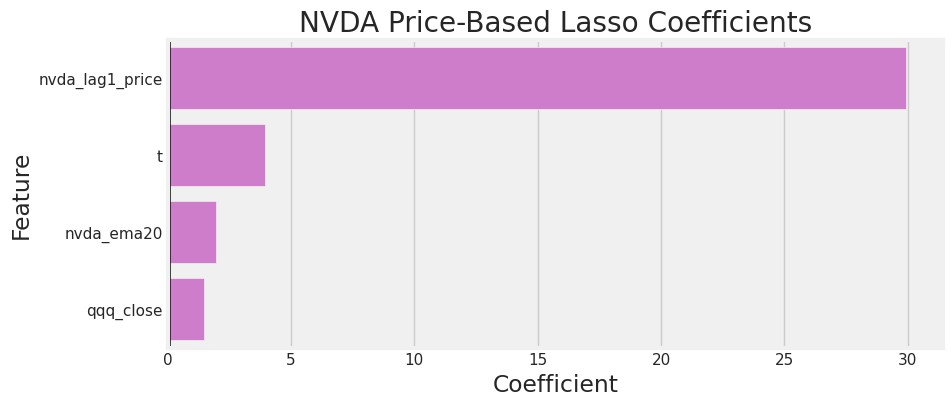

In [18]:
coef_df = pd.DataFrame({
    'Feature': X_cols_lasso,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df = coef_df.sort_values(by='Abs_Coefficient', key= abs, ascending=False)
display(coef_df.head(60))

plt.figure(figsize=(10,4))
plt.style.use('fivethirtyeight')
sns.barplot(data=coef_df, x='Coefficient', y ='Feature', color ='orchid')
plt.title('NVDA Price-Based Lasso Coefficients')
plt.axvline(0, color='black')
plt.savefig(os.path.join(assets_folder_path, 'lasso_coefficients.jpg'))

Although many engineered features were included, Lasso retains only a few key predictors—primarily NVDA’s lagged price, trend, and a limited set of market signals. The large number of zeroed coefficients suggests that many engineered features capture overlapping information, and removing them helped stabilize out-of-sample performance.

### Linear Regression Lasso Direct 30 Day Chart

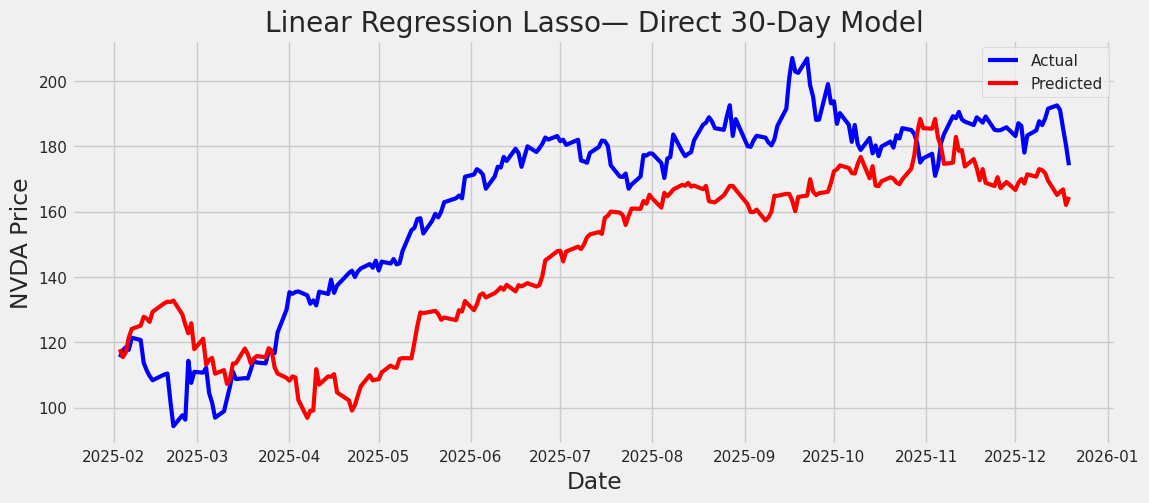

In [19]:
results_lasso
plt.figure(figsize=(12,5))
plt.plot(test_idx, y_test, label='Actual', color='blue', linewidth=3)
plt.plot(test_idx, y_pred, label='Predicted', color='red', linewidth=3)
plt.title('Linear Regression Lasso— Direct 30-Day Model')
plt.xlabel('Date')
plt.ylabel('NVDA Price')
plt.legend()
plt.savefig(os.path.join(assets_folder_path, 'lr_lasso_30day_forecast.jpg'))
plt.show()

The 30-day Lasso forecast captures the overall upward trend in NVDA’s price but smooths short-term fluctuations. The model follows the general trend direction of the series but reacts slowly to rapid price increases and declines. This behavior is consistent with the observed 30-day test RMSE (16.05), indicating moderate uncertainty over longer forecasting horizons.